<a href="https://colab.research.google.com/github/Pranayshukla0610/basic-python/blob/main/Basic_Statistics_using_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import requests
from bs4 import BeautifulSoup

In [2]:
url = "https://example-ecommerce-site.com/products"
headers = {"User-Agent": "Mozilla/5.0"}

response = requests.get(url, headers=headers)
soup = BeautifulSoup(response.text, "html.parser")

products = []
for item in soup.find_all("div", class_="product"):
    name = item.find("h2").text
    price = float(item.find("span", class_="price").text.replace("$",""))
    rating = float(item.find("span", class_="rating").text)
    reviews = int(item.find("span", class_="reviews").text)

    products.append([name, price, rating, reviews])

df = pd.DataFrame(products, columns=["Product", "Price", "Rating", "Reviews"])
df.to_csv("products.csv", index=False)

In [4]:
df = pd.read_csv('/content/upload-pricequotes202301.csv.zip')
df.head()

,QUOTE_DATE,ITEM_ID,ITEM_DESC,VALIDITY,SHOP_CODE,PRICE,INDICATOR_BOX,ORIG_INDICATOR_BOX,PRICE_RELATIVE,LOG_PRICE_RELATIVE,STRATUM_WEIGHT,STRATUM_TYPE,START_DATE,END_DATE,REGION,SHOP_TYPE,SHOP_WEIGHT,BASE_PRICE,BASE_VALIDITY,STRATUM_CELL
0,202301,210102,LGE LOAF-WHTE-UNSLED-750-800G,3,801,1.30,NaN,NaN,1.130,0.123,11.92,1,202202,999999,2,1,1,1.150,3,2
1,202301,210102,LGE LOAF-WHTE-UNSLED-750-800G,3,802,2.00,NaN,NaN,1.429,0.357,11.92,1,202202,999999,2,1,1,1.400,3,2
2,202301,210102,LGE LOAF-WHTE-UNSLED-750-800G,3,803,1.25,NaN,NaN,1.087,0.083,11.92,1,202202,999999,2,1,1,1.150,3,2
3,202301,210102,LGE LOAF-WHTE-UNSLED-750-800G,3,807,1.30,NaN,NaN,1.153,0.142,11.92,1,202204,999999,2,1,2,1.128,4,2
4,202301,210102,LGE LOAF-WHTE-UNSLED-750-800G,3,808,1.25,NaN,NaN,1.087,0.083,11.92,1,202202,999999,2,1,2,1.150,3,2


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 139419 entries, 0 to 139418
Data columns (total 20 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   QUOTE_DATE          139419 non-null  int64  
 1   ITEM_ID             139419 non-null  int64  
 2   ITEM_DESC           139419 non-null  object 
 3   VALIDITY            139419 non-null  int64  
 4   SHOP_CODE           139419 non-null  int64  
 5   PRICE               139419 non-null  float64
 6   INDICATOR_BOX       42864 non-null   object 
 7   ORIG_INDICATOR_BOX  41603 non-null   object 
 8   PRICE_RELATIVE      139419 non-null  float64
 9   LOG_PRICE_RELATIVE  139419 non-null  float64
 10  STRATUM_WEIGHT      139419 non-null  float64
 11  STRATUM_TYPE        139419 non-null  int64  
 12  START_DATE          139419 non-null  int64  
 13  END_DATE            139419 non-null  int64  
 14  REGION              139419 non-null  int64  
 15  SHOP_TYPE           139419 non-nul

In [6]:
df.describe()

,QUOTE_DATE,ITEM_ID,VALIDITY,SHOP_CODE,PRICE,PRICE_RELATIVE,LOG_PRICE_RELATIVE,STRATUM_WEIGHT,STRATUM_TYPE,START_DATE,END_DATE,REGION,SHOP_TYPE,SHOP_WEIGHT,BASE_PRICE,BASE_VALIDITY,STRATUM_CELL
count,139419.0,139419.000000,139419.000000,139419.000000,139419.000000,139419.000000,139419.000000,139419.000000,139419.000000,139419.000000,139419.0,139419.000000,139419.000000,139419.000000,139419.000000,139419.000000,139419.000000
mean,202301.0,376649.778997,2.895509,1040.958765,53.166161,1.026850,0.081656,29.656106,1.844254,202204.698040,999999.0,6.724586,1.331999,1.155438,53.015042,3.146451,4.868734
std,0.0,149600.411234,0.648717,2898.435704,250.069136,0.433982,0.234952,30.483255,0.972650,13.149712,0.0,3.422906,0.654715,0.759918,241.652598,0.588139,4.816566
min,202301.0,210102.000000,1.000000,1.000000,0.000000,0.000000,-2.701000,0.000000,0.000000,202202.000000,999999.0,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,202301.0,212712.000000,3.000000,41.000000,1.350000,1.000000,0.000000,7.740000,1.000000,202202.000000,999999.0,4.000000,1.000000,1.000000,1.750000,3.000000,1.000000
50%,202301.0,430127.000000,3.000000,92.000000,4.450000,1.062000,0.061000,11.360000,2.000000,202202.000000,999999.0,7.000000,1.000000,1.000000,5.000000,3.000000,3.000000
75%,202301.0,510349.000000,3.000000,904.000000,17.600000,1.193000,0.176000,71.650000,3.000000,202202.000000,999999.0,9.000000,1.000000,1.000000,18.000000,3.000000,8.000000
max,202301.0,640406.000000,4.000000,18550.000000,21000.000000,10.734000,2.373000,86.100000,3.000000,202301.000000,999999.0,13.000000,4.000000,21.000000,19971.857000,4.000000,26.000000


In [7]:
df.isnull().sum()

,0
QUOTE_DATE,0
ITEM_ID,0
ITEM_DESC,0
VALIDITY,0
SHOP_CODE,0
PRICE,0
INDICATOR_BOX,96555
ORIG_INDICATOR_BOX,97816
PRICE_RELATIVE,0
LOG_PRICE_RELATIVE,0


In [8]:
Q1 = df['PRICE'].quantile(0.25)
Q3 = df['PRICE'].quantile(0.75)

In [9]:
IQR = Q3 - Q1
df = df[(df['PRICE'] >= Q1 - 1.5 * IQR) &
        (df['PRICE'] <= Q3 + 1.5 * IQR)]

In [10]:
IQR

np.float64(16.25)

In [11]:
df['PRICE'].mean()

np.float64(7.088768805300493)

In [12]:
df['PRICE'].median()

3.15

In [13]:
df['PRICE'].mode()

,PRICE
0,0.0


In [14]:
df['PRICE'].var()

79.02811895047785

In [15]:
df['PRICE'].std()

8.889776091132884

In [16]:
df['PRICE'].skew()

np.float64(1.7954992932222644)

In [17]:
df['PRICE'].kurt()

np.float64(2.804135471854265)

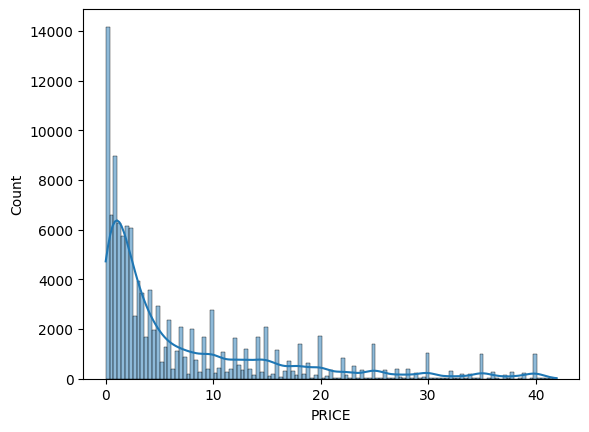

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df['PRICE'], kde=True)
plt.show()

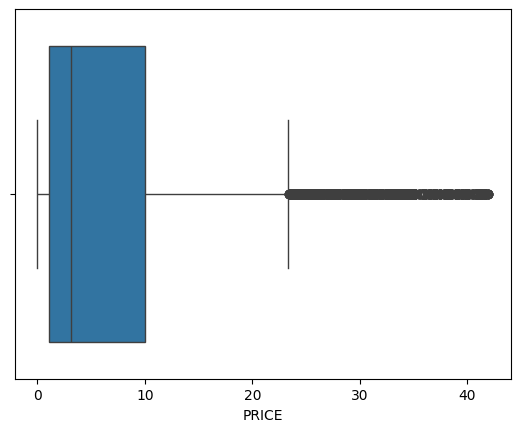

In [21]:
sns.boxplot(x=df['PRICE'])
plt.show()

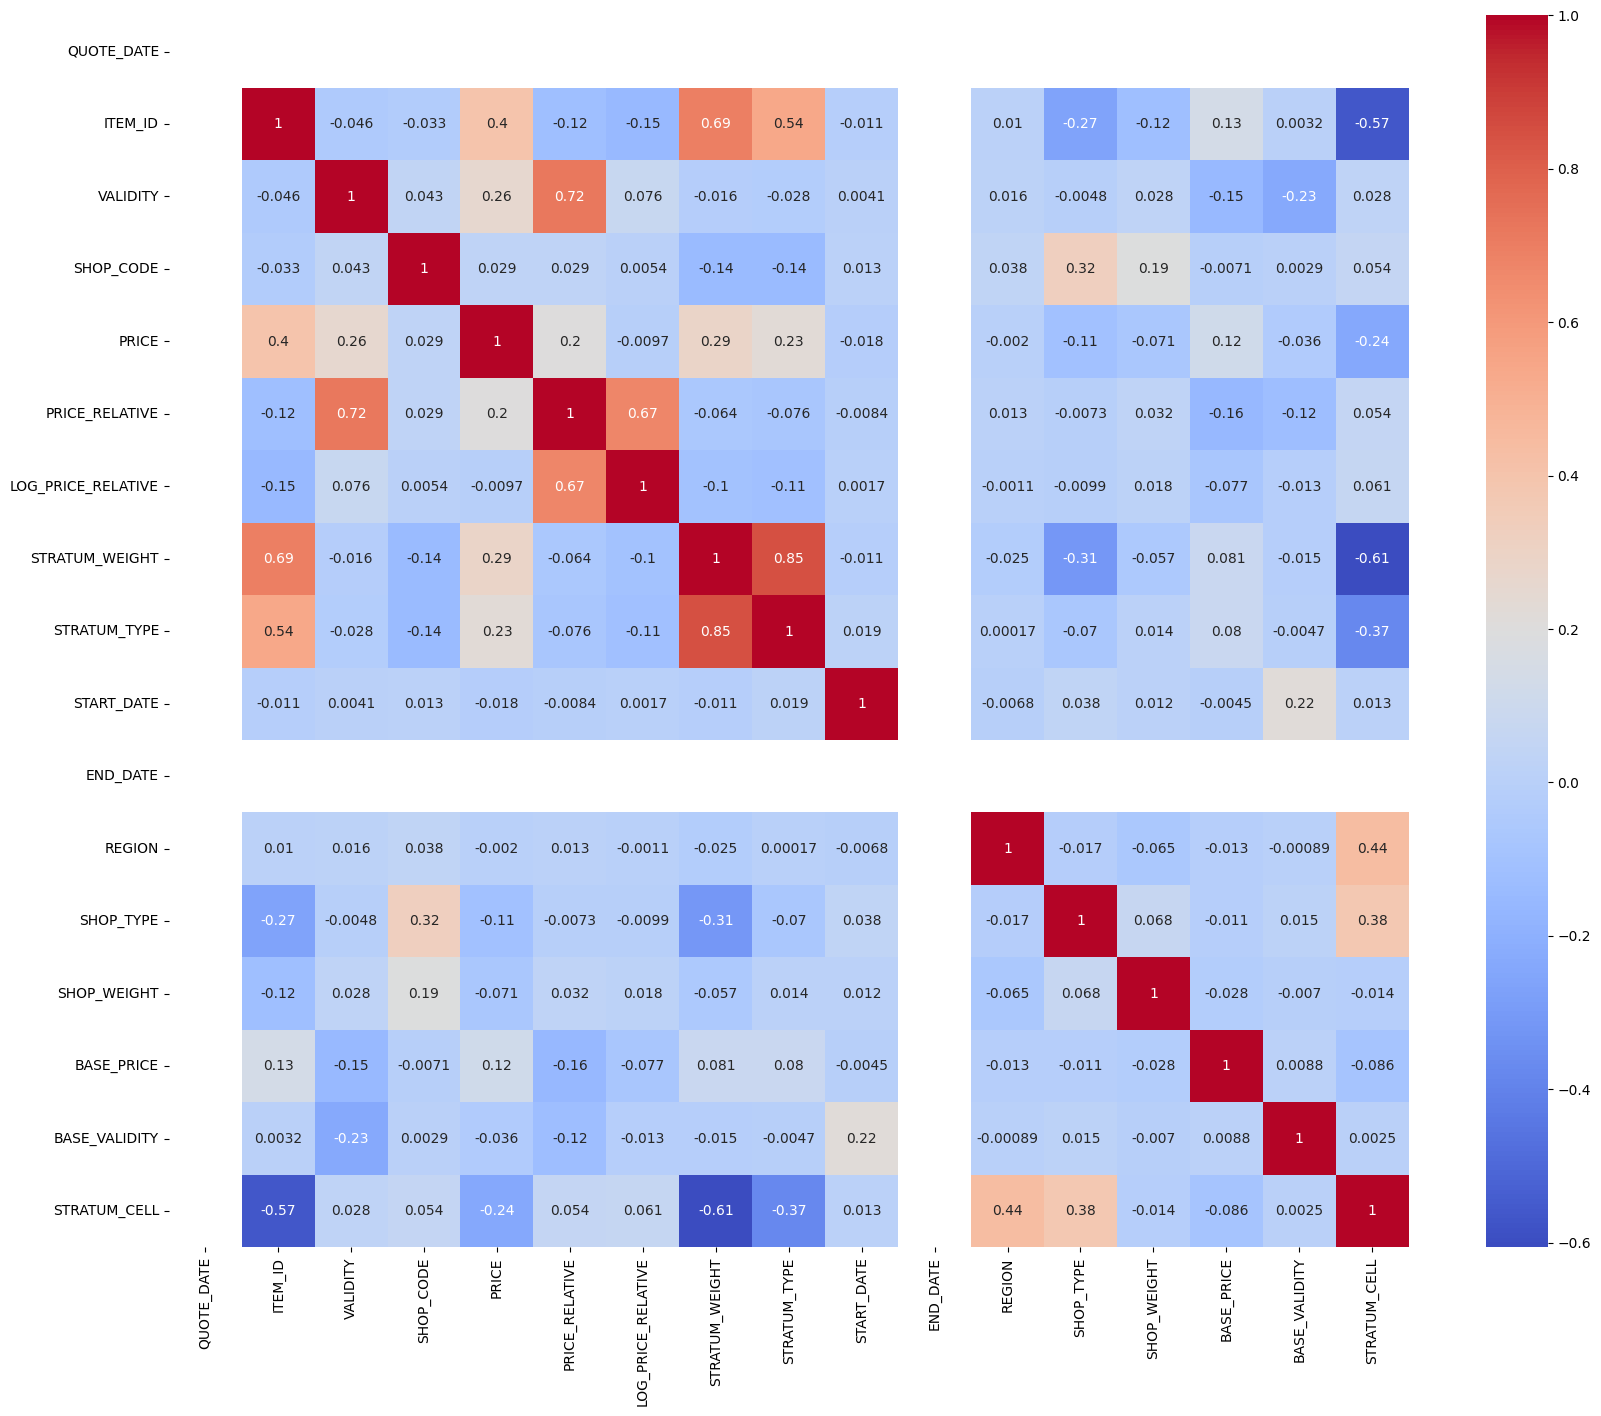

In [25]:
plt.figure(figsize=(20, 16))
sns.heatmap(df.select_dtypes(include='number').corr(),
            annot=True,
            cmap="coolwarm")
plt.show()

In [26]:
from scipy.stats import shapiro
stats, p = shapiro(df['PRICE'])
print("p-values",p)

p-values 3.401221585366812e-142


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 119687.
  res = hypotest_fun_out(*samples, **kwds)


In [28]:
from scipy.stats import ttest_ind
high = df[df['BASE_PRICE'] > 4]['PRICE']
low = df[df['BASE_PRICE'] < 4]['PRICE']

stats, p = ttest_ind(high, low)
print("p-values:",p)

p-values: 0.0
